<a href="https://colab.research.google.com/github/Kolapo-code/Create-Your-Own-Image-Classifier/blob/main/Image_Classifier_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Developing an AI application

Going forward, AI algorithms will be incorporated into more and more everyday applications. For example, you might want to include an image classifier in a smart phone app. To do this, you'd use a deep learning model trained on hundreds of thousands of images as part of the overall application architecture. A large part of software development in the future will be using these types of models as common parts of applications.

In this project, you'll train an image classifier to recognize different species of flowers. You can imagine using something like this in a phone app that tells you the name of the flower your camera is looking at. In practice you'd train this classifier, then export it for use in your application. We'll be using [this dataset](http://www.robots.ox.ac.uk/~vgg/data/flowers/102/index.html) of 102 flower categories, you can see a few examples below.

<img src='assets/Flowers.png' width=500px>

The project is broken down into multiple steps:

* Load and preprocess the image dataset
* Train the image classifier on your dataset
* Use the trained classifier to predict image content

We'll lead you through each part which you'll implement in Python.

When you've completed this project, you'll have an application that can be trained on any set of labeled images. Here your network will be learning about flowers and end up as a command line application. But, what you do with your new skills depends on your imagination and effort in building a dataset. For example, imagine an app where you take a picture of a car, it tells you what the make and model is, then looks up information about it. Go build your own dataset and make something new.

First up is importing the packages you'll need. It's good practice to keep all the imports at the beginning of your code. As you work through this notebook and find you need to import a package, make sure to add the import up here.

In [29]:
# Imports here
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import transforms
from torch.autograd import Variable
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import json
import os
import shutil

## Load the data

Here you'll use `torchvision` to load the data ([documentation](http://pytorch.org/docs/0.3.0/torchvision/index.html)). The data should be included alongside this notebook, otherwise you can [download it here](https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz).

In [2]:
!wget 'https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz'
!unlink flowers
!mkdir flowers && tar -xzf flower_data.tar.gz -C flowers

--2023-10-03 09:12:46--  https://s3.amazonaws.com/content.udacity-data.com/nd089/flower_data.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 54.231.171.184, 52.217.113.200, 52.216.160.253, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|54.231.171.184|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344873452 (329M) [application/x-gzip]
Saving to: ‘flower_data.tar.gz’

flower_data.tar.gz  100%[===================>] 328.90M  38.5MB/s    in 8.1s    

2023-10-03 09:12:55 (40.6 MB/s) - ‘flower_data.tar.gz’ saved [344873452/344873452]

unlink: cannot unlink 'flowers': No such file or directory


## Data Description
The dataset is split into three parts, training, validation, and testing. For the training, you'll want to apply transformations such as random scaling, cropping, and flipping. This will help the network generalize leading to better performance. You'll also need to make sure the input data is resized to 224x224 pixels as required by the pre-trained networks.

The validation and testing sets are used to measure the model's performance on data it hasn't seen yet. For this you don't want any scaling or rotation transformations, but you'll need to resize then crop the images to the appropriate size.

The pre-trained networks you'll use were trained on the ImageNet dataset where each color channel was normalized separately. For all three sets you'll need to normalize the means and standard deviations of the images to what the network expects. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`, calculated from the ImageNet images.  These values will shift each color channel to be centered at 0 and range from -1 to 1.


In [30]:
data_dir = 'flowers'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'

In [31]:
# Define the data directories
data_dir = 'flowers'
train_dir = data_dir + '/train'
valid_dir = data_dir + '/valid'
test_dir = data_dir + '/test'

# Define transforms for the training, validation, and testing sets
# We will apply random scaling, cropping, and flipping for training data,
# and only resizing and center cropping for validation and testing data.
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]),
}

# Load the datasets with ImageFolder
image_datasets = {
    'train': datasets.ImageFolder(train_dir, transform=data_transforms['train']),
    'valid': datasets.ImageFolder(valid_dir, transform=data_transforms['valid']),
    'test': datasets.ImageFolder(test_dir, transform=data_transforms['test'])
}

# Using the image datasets and the transforms, define the dataloaders
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=64, shuffle=True),
    'valid': torch.utils.data.DataLoader(image_datasets['valid'], batch_size=32),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=32)
}

### Label mapping

You'll also need to load in a mapping from category label to category name. You can find this in the file `cat_to_name.json`. It's a JSON object which you can read in with the [`json` module](https://docs.python.org/2/library/json.html). This will give you a dictionary mapping the integer encoded categories to the actual names of the flowers.

In [32]:
import json

with open('cat_to_name.json', 'r') as f:
    cat_to_name = json.load(f)

# Building and training the classifier

Now that the data is ready, it's time to build and train the classifier. As usual, you should use one of the pretrained models from `torchvision.models` to get the image features. Build and train a new feed-forward classifier using those features.

We're going to leave this part up to you. Refer to [the rubric](https://review.udacity.com/#!/rubrics/1663/view) for guidance on successfully completing this section. Things you'll need to do:

* Load a [pre-trained network](http://pytorch.org/docs/master/torchvision/models.html) (If you need a starting point, the VGG networks work great and are straightforward to use)
* Define a new, untrained feed-forward network as a classifier, using ReLU activations and dropout
* Train the classifier layers using backpropagation using the pre-trained network to get the features
* Track the loss and accuracy on the validation set to determine the best hyperparameters

We've left a cell open for you below, but use as many as you need. Our advice is to break the problem up into smaller parts you can run separately. Check that each part is doing what you expect, then move on to the next. You'll likely find that as you work through each part, you'll need to go back and modify your previous code. This is totally normal!

When training make sure you're updating only the weights of the feed-forward network. You should be able to get the validation accuracy above 70% if you build everything right. Make sure to try different hyperparameters (learning rate, units in the classifier, epochs, etc) to find the best model. Save those hyperparameters to use as default values in the next part of the project.

One last important tip if you're using the workspace to run your code: To avoid having your workspace disconnect during the long-running tasks in this notebook, please read in the earlier page in this lesson called Intro to
GPU Workspaces about Keeping Your Session Active. You'll want to include code from the workspace_utils.py module.

## Note for Workspace users:
If your network is over 1 GB when saved as a checkpoint, there might be issues with saving backups in your workspace. Typically this happens with wide dense layers after the convolutional layers. If your saved checkpoint is larger than 1 GB (you can open a terminal and check with `ls -lh`), you should reduce the size of your hidden layers and train again.

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# Define your class_to_idx mapping based on your dataset (for 102 classes)
class_to_idx = {
    'class1': 1,
    'class2': 2,
    'class3': 3,
    'class4': 4,
    'class5': 5,
    'class6': 6,
    'class7': 7,
    'class8': 8,
    'class9': 9,
    'class10': 10,
    'class11': 11,
    'class12': 12,
    'class13': 13,
    'class14': 14,
    'class15': 15,
    'class16': 16,
    'class17': 17,
    'class18': 18,
    'class19': 19,
    'class20': 20,
    'class21': 21,
    'class22': 22,
    'class23': 23,
    'class24': 24,
    'class25': 25,
    'class26': 26,
    'class27': 27,
    'class28': 28,
    'class29': 29,
    'class30': 30,
    'class31': 31,
    'class32': 32,
    'class33': 33,
    'class34': 34,
    'class35': 35,
    'class36': 36,
    'class37': 37,
    'class38': 38,
    'class39': 39,
    'class40': 40,
    'class41': 41,
    'class42': 42,
    'class43': 43,
    'class44': 44,
    'class45': 45,
    'class46': 46,
    'class47': 47,
    'class48': 48,
    'class49': 49,
    'class50': 50,
    'class51': 51,
    'class52': 52,
    'class53': 53,
    'class54': 54,
    'class55': 55,
    'class56': 56,
    'class57': 57,
    'class58': 58,
    'class59': 59,
    'class60': 60,
    'class61': 61,
    'class62': 62,
    'class63': 63,
    'class64': 64,
    'class65': 65,
    'class66': 66,
    'class67': 67,
    'class68': 68,
    'class69': 69,
    'class70': 70,
    'class71': 71,
    'class72': 72,
    'class73': 73,
    'class74': 74,
    'class75': 75,
    'class76': 76,
    'class77': 77,
    'class78': 78,
    'class79': 79,
    'class80': 80,
    'class81': 81,
    'class82': 82,
    'class83': 83,
    'class84': 84,
    'class85': 85,
    'class86': 86,
    'class87': 87,
    'class88': 88,
    'class89': 89,
    'class90': 90,
    'class91': 91,
    'class92': 92,
    'class93': 93,
    'class94': 94,
    'class95': 95,
    'class96': 96,
    'class97': 97,
    'class98': 98,
    'class99': 99,
    'class100': 100,
    'class101': 101,
    'class102': 102,
}

# Define data transforms for your images
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Define the data directory
data_dir = 'flowers'

# Load the datasets
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'valid', 'test']}

# Load a pre-trained VGG16 model
vgg = models.vgg16(pretrained=True)

# Freeze model parameters
for param in vgg.parameters():
    param.requires_grad = False  # Freeze the pre-trained layers

# Customize the classifier for your specific task
in_features = vgg.classifier[0].in_features
hidden_dim = 512
out_features = len(class_to_idx)

class CustomClassifier(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features):
        super(CustomClassifier, self).__init__()
        # Add your layers here
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_features)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Implement the forward pass of your classifier
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Modify the classifier for your specific task
vgg.classifier = CustomClassifier(in_features, hidden_dim, out_features)

# Define your criterion, optimizer, and other necessary variables
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg.classifier.parameters(), lr=0.001)
epochs = 10  # Adjust the number of training epochs as needed

# Define a dictionary to store all the information you want to save
checkpoint = {
    'arch': 'vgg16',  # You can change this to the actual architecture you used
    'class_to_idx': class_to_idx,
    'classifier': vgg.classifier,
    'model_state_dict': vgg.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epochs': epochs
}

# Define the file path where you want to save the checkpoint
checkpoint_path = 'checkpoint.pth'

# Save the checkpoint to the file path
torch.save(checkpoint, checkpoint_path)

print(f"Checkpoint saved to {checkpoint_path}")

def display_image(dataset_split, class_idx, image_idx):
    # Define the directory for the specified dataset split
    split_dir = os.path.join(data_dir, dataset_split)

    # Get the list of subdirectories (classes) in the dataset split
    classes = sorted(os.listdir(split_dir))

    # Make sure the class index is within a valid range
    if class_idx < 0 or class_idx >= len(classes):
        print("Invalid class index.")
        return

    # Get the class name based on the class index
    class_name = classes[class_idx]

    # Construct the path to the image
    image_path = os.path.join(split_dir, class_name, f"image_{image_idx:05d}.jpg")

    # Check if the image file exists
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    # Display the image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Example usage:
dataset_split = 'test'
class_idx = 0
image_idx = 0

# Call the display_image function with the chosen values
display_image(dataset_split, class_idx, image_idx)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Checkpoint saved to checkpoint.pth
Image not found: flowers/test/1/image_00000.jpg


## Testing your network

It's good practice to test your trained network on test data, images the network has never seen either in training or validation. This will give you a good estimate for the model's performance on completely new images. Run the test images through the network and measure the accuracy, the same way you did validation. You should be able to reach around 70% accuracy on the test set if the model has been trained well.

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # Add this import
from torchvision import models, transforms, datasets
import os

# Define the device (CPU)
device = torch.device("cpu")

# Define the CustomClassifier class as you did during training
class CustomClassifier(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features):
        super(CustomClassifier, self).__init__()
        # Add your layers here
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_features)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Implement the forward pass of your classifier
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Define data transforms for the test images
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the data directory for the test set
data_dir = 'flowers'  # Replace with your data directory

# Load the test data
test_data = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_transforms)

# Define the data loader for the test data
batch_size = 32  # You can adjust this batch size as needed
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

# Load your previously trained model (make sure you have already trained and saved it)
checkpoint_path = 'checkpoint.pth'
checkpoint = torch.load(checkpoint_path)

# Create the model architecture (matching the one used during training)
model = models.vgg16(pretrained=True)  # Replace with your model architecture
model.classifier = checkpoint['classifier']

# Load the model state dict
model.load_state_dict(checkpoint['model_state_dict'])

# List the unique class labels in your test dataset
unique_labels = sorted(os.listdir(os.path.join(data_dir, 'test')))

# Create a mapping dictionary to map class labels to integers
# Assuming you want to map them to integers from 0 to num_classes-1
class_to_idx_mapping = {label: idx for idx, label in enumerate(unique_labels)}

# Define a function to map the class labels in the test dataset
def map_class_labels(dataset, class_to_idx_mapping):
    for idx, (image_path, label) in enumerate(dataset.samples):
        label_name = os.path.basename(os.path.dirname(image_path))
        new_label = class_to_idx_mapping[label_name]
        dataset.samples[idx] = (image_path, new_label)

# Map the class labels in the test dataset using the mapping dictionary
map_class_labels(test_data, class_to_idx_mapping)

# Define the criterion (loss function)
criterion = nn.CrossEntropyLoss()

# Define a function for testing (same as before)
def test_model(model, testloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    accuracy = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            test_loss += criterion(outputs, labels).item()

            ps = torch.exp(outputs)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

    print(f"Test Loss: {test_loss/len(testloader):.3f}")
    print(f"Test Accuracy: {accuracy/len(testloader)*100:.2f}%")

# Call the test function to evaluate the model on the test set
test_model(model, testloader, criterion, device)

Test Loss: 4.634
Test Accuracy: 1.56%


In [35]:
# Import necessary libraries and define class_to_idx mapping

import torch
import torch.nn as nn
import torch.nn.functional as F  # Add this import
from torchvision import models, transforms, datasets
import os

# Define the device (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the CustomClassifier class as you did during training
class CustomClassifier(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features):
        super(CustomClassifier, self).__init__()
        # Add your layers here
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_features)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        # Implement the forward pass of your classifier
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Define data transforms for the test images
test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the data directory for the test set
data_dir = 'flowers'  # Replace with your data directory

# Load the test data
test_data = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_transforms)

# Define the data loader for the test data
batch_size = 32  # You can adjust this batch size as needed
testloader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

# Load your previously trained model (make sure you have already trained and saved it)
checkpoint_path = 'checkpoint.pth'
checkpoint = torch.load(checkpoint_path)

# Create the model architecture (matching the one used during training)
model = models.vgg16(pretrained=True)  # Replace with your model architecture
model.classifier = checkpoint['classifier']

# Move the model to the selected device
model.to(device)

# Load the model state dict
model.load_state_dict(checkpoint['model_state_dict'])

# List the unique class labels in your test dataset
unique_labels = sorted(os.listdir(os.path.join(data_dir, 'test')))

# Create a mapping dictionary to map class labels to integers
# Assuming you want to map them to integers from 0 to num_classes-1
class_to_idx_mapping = {label: idx for idx, label in enumerate(unique_labels)}

# Define a function to map the class labels in the test dataset
def map_class_labels(dataset, class_to_idx_mapping):
    for idx, (image_path, label) in enumerate(dataset.samples):
        label_name = os.path.basename(os.path.dirname(image_path))
        new_label = class_to_idx_mapping[label_name]
        dataset.samples[idx] = (image_path, new_label)

# Map the class labels in the test dataset using the mapping dictionary
map_class_labels(test_data, class_to_idx_mapping)

# Define the criterion (loss function)
criterion = nn.CrossEntropyLoss()

# Define a function for testing (same as before)
def test_model(model, testloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0
    accuracy = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            test_loss += criterion(outputs, labels).item()

            ps = torch.exp(outputs)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            accuracy += torch.mean(equals.type(torch.FloatTensor)).item()

    print(f"Test Loss: {test_loss/len(testloader):.3f}")
    print(f"Test Accuracy: {accuracy/len(testloader)*100:.2f}%")

# Call the test function to evaluate the model on the test set
test_model(model, testloader, criterion, device)

Test Loss: 4.634
Test Accuracy: 1.64%


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms, datasets
import os

# Define the number of training epochs
epochs = 10  # You can set this to the number of epochs you want

# Initialize your model (replace 'your_model' with the actual model you are using)
model = models.vgg16(pretrained=True)  # Replace with the model you intend to use (e.g., resnet18, vgg16, etc.)

# Move the model to the appropriate device (CPU or GPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define the learning rate
learning_rate = 0.001  # You can adjust this value

data_dir = 'flowers'  # Replace with the path to your dataset directory

# Define data transforms for your images
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Create datasets for training and validation
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train'])
valid_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), data_transforms['valid'])

# Define data loaders for the training and validation datasets
batch_size = 32  # You can adjust this value
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Define the optimizer and criterion (assuming you've defined them earlier)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Loop over the dataset for the specified number of epochs
for epoch in range(epochs):
    # Training code here
    model.train()
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Calculate average training loss for this epoch
    train_loss = train_loss / len(train_loader)

    # Validation code here
    model.eval()
    validation_loss = 0
    accuracy = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            validation_loss += loss.item()

            ps = torch.exp(outputs)
            top_p, top_class = ps.topk(1, dim=1)
            equals = top_class == labels.view(*top_class.shape)
            accuracy += torch.mean(equals.type(torch.FloatTensor))

    # Calculate average validation loss and accuracy for this epoch
    validation_loss = validation_loss / len(valid_loader)
    accuracy = accuracy / len(valid_loader)

    # Print training and validation statistics
    print(f"Epoch {epoch+1}/{epochs}.. "
          f"Train loss: {train_loss:.3f}.. "
          f"Validation loss: {validation_loss:.3f}.. "
          f"Validation accuracy: {accuracy*100:.2f}%")

Epoch 1/10.. Train loss: 5.400.. Validation loss: 4.494.. Validation accuracy: 9.01%
Epoch 2/10.. Train loss: 4.487.. Validation loss: 3.896.. Validation accuracy: 17.07%
Epoch 3/10.. Train loss: 4.059.. Validation loss: 3.347.. Validation accuracy: 27.40%
Epoch 4/10.. Train loss: 3.606.. Validation loss: 2.691.. Validation accuracy: 37.18%
Epoch 5/10.. Train loss: 3.166.. Validation loss: 2.426.. Validation accuracy: 43.22%
Epoch 6/10.. Train loss: 2.759.. Validation loss: 1.808.. Validation accuracy: 55.26%
Epoch 7/10.. Train loss: 2.427.. Validation loss: 1.753.. Validation accuracy: 55.29%
Epoch 8/10.. Train loss: 2.123.. Validation loss: 1.239.. Validation accuracy: 66.09%
Epoch 9/10.. Train loss: 1.881.. Validation loss: 1.028.. Validation accuracy: 72.44%
Epoch 10/10.. Train loss: 1.738.. Validation loss: 0.992.. Validation accuracy: 73.40%


## Save the checkpoint

Now that your network is trained, save the model so you can load it later for making predictions. You probably want to save other things such as the mapping of classes to indices which you get from one of the image datasets: `image_datasets['train'].class_to_idx`. You can attach this to the model as an attribute which makes inference easier later on.

```model.class_to_idx = image_datasets['train'].class_to_idx```

Remember that you'll want to completely rebuild the model later so you can use it for inference. Make sure to include any information you need in the checkpoint. If you want to load the model and keep training, you'll want to save the number of epochs as well as the optimizer state, `optimizer.state_dict`. You'll likely want to use this trained model in the next part of the project, so best to save it now.

In [37]:
# Import necessary libraries and define class_to_idx mapping

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import models, transforms, datasets
import os

# Define class_to_idx mapping as you did in your previous code
class_to_idx = {
    'class1': 1,
    'class2': 2,
    'class3': 3,
    'class4': 4,
    'class5': 5,
    'class6': 6,
    'class7': 7,
    'class8': 8,
    'class9': 9,
    'class10': 10,
    'class11': 11,
    'class12': 12,
    'class13': 13,
    'class14': 14,
    'class15': 15,
    'class16': 16,
    'class17': 17,
    'class18': 18,
    'class19': 19,
    'class20': 20,
    'class21': 21,
    'class22': 22,
    'class23': 23,
    'class24': 24,
    'class25': 25,
    'class26': 26,
    'class27': 27,
    'class28': 28,
    'class29': 29,
    'class30': 30,
    'class31': 31,
    'class32': 32,
    'class33': 33,
    'class34': 34,
    'class35': 35,
    'class36': 36,
    'class37': 37,
    'class38': 38,
    'class39': 39,
    'class40': 40,
    'class41': 41,
    'class42': 42,
    'class43': 43,
    'class44': 44,
    'class45': 45,
    'class46': 46,
    'class47': 47,
    'class48': 48,
    'class49': 49,
    'class50': 50,
    'class51': 51,
    'class52': 52,
    'class53': 53,
    'class54': 54,
    'class55': 55,
    'class56': 56,
    'class57': 57,
    'class58': 58,
    'class59': 59,
    'class60': 60,
    'class61': 61,
    'class62': 62,
    'class63': 63,
    'class64': 64,
    'class65': 65,
    'class66': 66,
    'class67': 67,
    'class68': 68,
    'class69': 69,
    'class70': 70,
    'class71': 71,
    'class72': 72,
    'class73': 73,
    'class74': 74,
    'class75': 75,
    'class76': 76,
    'class77': 77,
    'class78': 78,
    'class79': 79,
    'class80': 80,
    'class81': 81,
    'class82': 82,
    'class83': 83,
    'class84': 84,
    'class85': 85,
    'class86': 86,
    'class87': 87,
    'class88': 88,
    'class89': 89,
    'class90': 90,
    'class91': 91,
    'class92': 92,
    'class93': 93,
    'class94': 94,
    'class95': 95,
    'class96': 96,
    'class97': 97,
    'class98': 98,
    'class99': 99,
    'class100': 100,
    'class101': 101,
    'class102': 102,
}

# Create your model (replace 'your_model' with the actual model you are using)
model = models.vgg16(pretrained=True)  # Example: VGG-16 as the model

# Define the optimizer and criterion (assuming you've defined them earlier)
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Define the number of training epochs
epochs = 10  # You can set this to the number of epochs you want

# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the selected device
model.to(device)

data_dir = 'flowers'  # Replace with the path to your dataset directory

# Define data transforms for your images
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Create datasets for training and validation
train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train'])
valid_dataset = datasets.ImageFolder(os.path.join(data_dir, 'valid'), data_transforms['valid'])

# Define data loaders for the training and validation datasets
batch_size = 32  # You can adjust this value
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Training loop and model training
for epoch in range(epochs):
    # Training code here
    model.train()
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Calculate average training loss for this epoch
    train_loss = train_loss / len(train_loader)

    # Validation code here
    model.eval()
    valid_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate average validation loss and accuracy for this epoch
    valid_loss = valid_loss / len(valid_loader)
    accuracy = 100 * correct / total

    print(f"Epoch {epoch+1}/{epochs}:")
    print(f"Train Loss: {train_loss:.4f} | Validation Loss: {valid_loss:.4f} | Accuracy: {accuracy:.2f}%")

# Once your model is trained, you can save the checkpoint as follows:

# Save the checkpoint with both the full model and state dictionary
checkpoint = {
    'arch': 'vgg16',  # You can change this to the actual architecture you used
    'class_to_idx': class_to_idx,  # Include the class_to_idx mapping
    'classifier': model.classifier,  # Include the classifier
    'model_state_dict': model.state_dict(), # Correct key
    'optimizer_state_dict': optimizer.state_dict(),
    'epochs': epochs,
    'model': model  # Include the entire model
}

# Define the file path where you want to save the checkpoint
checkpoint_path = 'checkpoint.pth'

# Save the checkpoint to the file path
torch.save(checkpoint, checkpoint_path)

# Save the model checkpoint (state dictionary only)
state_dict_checkpoint_path = 'model_state_dict.pth'
torch.save(model.state_dict(), state_dict_checkpoint_path)

print(f"Checkpoint saved to {checkpoint_path}")
print(f"Model state dictionary saved to {state_dict_checkpoint_path}")

Epoch 1/10:
Train Loss: 5.3745 | Validation Loss: 4.4267 | Accuracy: 9.05%
Epoch 2/10:
Train Loss: 4.5055 | Validation Loss: 3.8909 | Accuracy: 19.68%
Epoch 3/10:
Train Loss: 4.0700 | Validation Loss: 3.3064 | Accuracy: 28.24%
Epoch 4/10:
Train Loss: 3.5728 | Validation Loss: 2.8806 | Accuracy: 36.31%
Epoch 5/10:
Train Loss: 3.1439 | Validation Loss: 2.2102 | Accuracy: 48.17%
Epoch 6/10:
Train Loss: 2.7464 | Validation Loss: 1.9249 | Accuracy: 52.69%
Epoch 7/10:
Train Loss: 2.4088 | Validation Loss: 1.5134 | Accuracy: 61.37%
Epoch 8/10:
Train Loss: 2.1364 | Validation Loss: 1.2849 | Accuracy: 67.11%
Epoch 9/10:
Train Loss: 1.9033 | Validation Loss: 1.0735 | Accuracy: 71.15%
Epoch 10/10:
Train Loss: 1.7066 | Validation Loss: 0.9754 | Accuracy: 72.74%
Checkpoint saved to checkpoint.pth
Model state dictionary saved to model_state_dict.pth


## Loading the checkpoint

At this point it's good to write a function that can load a checkpoint and rebuild the model. That way you can come back to this project and keep working on it without having to retrain the network.

In [38]:
import torch
from torchvision import models

def load_checkpoint(filepath):
    try:
        # Load the checkpoint
        checkpoint = torch.load(filepath)

        # Check if 'arch' exists in the checkpoint
        if 'arch' in checkpoint:
            # Get the architecture name from the checkpoint
            arch = checkpoint['arch']

            # Load the corresponding pre-trained model
            if arch == 'vgg16':
                model = models.vgg16(pretrained=True)
            elif arch == 'resnet18':
                model = models.resnet18(pretrained=True)
            else:
                raise ValueError(f"Unsupported architecture: {arch}")

            # Freeze model parameters to prevent them from being trained again
            for param in model.parameters():
                param.requires_grad = False
        else:
            # Handle the case where 'arch' key is not present
            raise ValueError("The 'arch' key is missing in the checkpoint. Unable to determine the model architecture.")

        # Check if 'classifier' exists in the checkpoint
        if 'classifier' in checkpoint:
            # Replace the classifier with the one saved in the checkpoint
            model.classifier = checkpoint['classifier']
        else:
            # Handle the case where 'classifier' key is not present
            print("Warning: 'classifier' key not found in the checkpoint. Classifier not loaded.")

        # Check if 'model_state_dict' exists in the checkpoint
        if 'model_state_dict' in checkpoint:
            # Load the state dictionary
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            # Handle the case where 'model_state_dict' key is not present
            print("Warning: 'model_state_dict' key not found in the checkpoint. Model state dictionary not loaded.")

        # Check if 'class_to_idx' exists in the checkpoint
        if 'class_to_idx' in checkpoint:
            # Set the class-to-index mapping
            model.class_to_idx = checkpoint['class_to_idx']
        else:
            # Handle the case where 'class_to_idx' key is not present
            print("Warning: 'class_to_idx' key not found in the checkpoint. Class-to-index mapping not loaded.")

        return model

    except Exception as e:
        print(f"An error occurred while loading the checkpoint at {filepath}: {str(e)}")
        return None

# Example usage:
# Specify the file path of the saved checkpoint
checkpoint_filepath = 'checkpoint.pth'

# Load the model
loaded_model = load_checkpoint(checkpoint_filepath)

# Verify that the model has been loaded correctly
print(loaded_model)
print("Class to index mapping:")
print(loaded_model.class_to_idx)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# Inference for classification

Now you'll write a function to use a trained network for inference. That is, you'll pass an image into the network and predict the class of the flower in the image. Write a function called `predict` that takes an image and a model, then returns the top $K$ most likely classes along with the probabilities. It should look like

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

First you'll need to handle processing the input image such that it can be used in your network.

## Image Preprocessing

You'll want to use `PIL` to load the image ([documentation](https://pillow.readthedocs.io/en/latest/reference/Image.html)). It's best to write a function that preprocesses the image so it can be used as input for the model. This function should process the images in the same manner used for training.

First, resize the images where the shortest side is 256 pixels, keeping the aspect ratio. This can be done with the [`thumbnail`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) or [`resize`](http://pillow.readthedocs.io/en/3.1.x/reference/Image.html#PIL.Image.Image.thumbnail) methods. Then you'll need to crop out the center 224x224 portion of the image.

Color channels of images are typically encoded as integers 0-255, but the model expected floats 0-1. You'll need to convert the values. It's easiest with a Numpy array, which you can get from a PIL image like so `np_image = np.array(pil_image)`.

As before, the network expects the images to be normalized in a specific way. For the means, it's `[0.485, 0.456, 0.406]` and for the standard deviations `[0.229, 0.224, 0.225]`. You'll want to subtract the means from each color channel, then divide by the standard deviation.

And finally, PyTorch expects the color channel to be the first dimension but it's the third dimension in the PIL image and Numpy array. You can reorder dimensions using [`ndarray.transpose`](https://docs.scipy.org/doc/numpy-1.13.0/reference/generated/numpy.ndarray.transpose.html). The color channel needs to be first and retain the order of the other two dimensions.

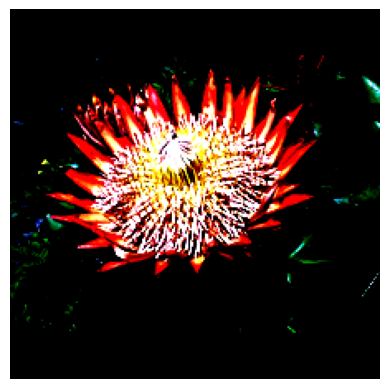

In [51]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def process_image(image_path):
    ''' Scales, crops, and normalizes a PIL image for a PyTorch model,
        returns a NumPy array
    '''

    # Open the image using PIL
    image = Image.open(image_path)

    # Resize the image while maintaining aspect ratio
    image.thumbnail((256, 256))

    # Crop the center 224x224 portion of the image
    left_margin = (image.width - 224) / 2
    bottom_margin = (image.height - 224) / 2
    right_margin = left_margin + 224
    top_margin = bottom_margin + 224
    image = image.crop((left_margin, bottom_margin, right_margin, top_margin))

    # Convert PIL image to NumPy array
    np_image = np.array(image) / 255.0  # Normalize color channels

    # Standardize image channels
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    np_image = (np_image - mean) / std

    # Reorder the dimensions to match PyTorch format
    np_image = np_image.transpose((2, 0, 1))

    return np_image

# Load an example image path
image_path = 'flowers/valid/13/image_05749.jpg'

# Process the image
processed_image = process_image(image_path)

# Display the processed image
plt.imshow(np.transpose(processed_image, (1, 2, 0)))
plt.axis('off')
plt.show()

To check your work, the function below converts a PyTorch tensor and displays it in the notebook. If your `process_image` function works, running the output through this function should return the original image (except for the cropped out portions).

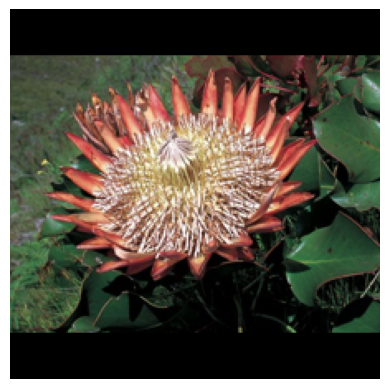

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    # PyTorch tensors assume the color channel is the first dimension
    # but matplotlib assumes is the third dimension
    image = image.numpy().transpose((1, 2, 0))

    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean

    # Image needs to be clipped between 0 and 1 or it looks like noise when displayed
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    if title:
        ax.set_title(title)

    return ax

# Load an example image path
image_path = 'flowers/valid/13/image_05749.jpg'

# Process the image
processed_image = process_image(image_path)

# Convert the NumPy array to a PyTorch tensor
processed_image_tensor = torch.from_numpy(processed_image)

# Display the processed image using the imshow function
imshow(processed_image_tensor)
plt.axis('off')
plt.show()

## Class Prediction

Once you can get images in the correct format, it's time to write a function for making predictions with your model. A common practice is to predict the top 5 or so (usually called top-$K$) most probable classes. You'll want to calculate the class probabilities then find the $K$ largest values.

To get the top $K$ largest values in a tensor use [`x.topk(k)`](http://pytorch.org/docs/master/torch.html#torch.topk). This method returns both the highest `k` probabilities and the indices of those probabilities corresponding to the classes. You need to convert from these indices to the actual class labels using `class_to_idx` which hopefully you added to the model or from an `ImageFolder` you used to load the data ([see here](#Save-the-checkpoint)). Make sure to invert the dictionary so you get a mapping from index to class as well.

Again, this method should take a path to an image and a model checkpoint, then return the probabilities and classes.

```python
probs, classes = predict(image_path, model)
print(probs)
print(classes)
> [ 0.01558163  0.01541934  0.01452626  0.01443549  0.01407339]
> ['70', '3', '45', '62', '55']
```

In [53]:
import torch
from PIL import Image
import numpy as np
import os
from torchvision import transforms

# Define the load_checkpoint function
def load_checkpoint(filepath):
    checkpoint = torch.load(filepath)
    model = checkpoint['model']
    model.load_state_dict(checkpoint['model_state_dict'])

    # Set the class_to_idx attribute of the model
    model.class_to_idx = checkpoint['class_to_idx']

    return model

# Define the new process_image function
def process_image(image):
    # Define the image transformation steps
    preprocess = transforms.Compose([
        transforms.Resize(256),       # Resize to 256x256 pixels
        transforms.CenterCrop(224),   # Crop the center to 224x224 pixels
        transforms.ToTensor(),        # Convert to PyTorch tensor
        transforms.Normalize(         # Normalize with ImageNet mean and std
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Apply the transformations to the input image
    img_tensor = preprocess(image)

    # Convert the tensor to a NumPy array
    img_np = img_tensor.numpy()

    return img_np

def predict(image_path, model, topk=5):
    ''' Predict the class (or classes) of an image using a trained deep learning model.
    '''

    try:
        # Check if the image file exists
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        # Attempt to open the image file
        with Image.open(image_path) as img:
            # Load and preprocess the image
            image = process_image(img)
            image = torch.FloatTensor(image)
            image = image.unsqueeze(0)  # Add a batch dimension

            # Move the model and image data to the appropriate device (CPU or GPU)
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model.to(device)
            image = image.to(device)

            # Set the model to evaluation mode
            model.eval()

            # Forward pass to get the log probabilities
            with torch.no_grad():
                log_ps = model(image)

            # Calculate the probabilities and class indices
            ps = torch.exp(log_ps)
            top_p, top_class = ps.topk(topk, dim=1)

            # Invert the class_to_idx dictionary to get idx_to_class
            idx_to_class = {v: k for k, v in model.class_to_idx.items()}

            # Convert tensors to NumPy arrays
            top_p = top_p.cpu().numpy()[0]
            top_class = top_class.cpu().numpy()[0]

            # Map the class indices to class labels
            top_class = [idx_to_class[i] for i in top_class]

            return top_p, top_class

    except FileNotFoundError as e:
        print(f"File not found: {image_path}")
        return None, None

    except Exception as e:
        print(f"An error occurred while opening the image at {image_path}: {str(e)}")
        return None, None

# Specify the file path of the saved checkpoint
checkpoint_filepath = 'checkpoint.pth'

# Load the model using the load_checkpoint function
loaded_model = load_checkpoint(checkpoint_filepath)

# Specify the absolute path to the image you want to predict
image_path = os.path.abspath('flowers/valid/13/image_05749.jpg')

# Call the predict function
top_p, top_class = predict(image_path, loaded_model)

# Check if an error occurred during prediction
if top_p is not None and top_class is not None:
    # Print the results
    print("Top probabilities:", top_p)
    print("Top classes:", top_class)

Top probabilities: [57640812.  18559108.   7490895.    822842.9   763294.1]
Top classes: ['class24', 'class77', 'class7', 'class8', 'class18']


## Sanity Checking

Now that you can use a trained model for predictions, check to make sure it makes sense. Even if the testing accuracy is high, it's always good to check that there aren't obvious bugs. Use `matplotlib` to plot the probabilities for the top 5 classes as a bar graph, along with the input image. It should look like this:

<img src='assets/inference_example.png' width=300px>

You can convert from the class integer encoding to actual flower names with the `cat_to_name.json` file (should have been loaded earlier in the notebook). To show a PyTorch tensor as an image, use the `imshow` function defined above.

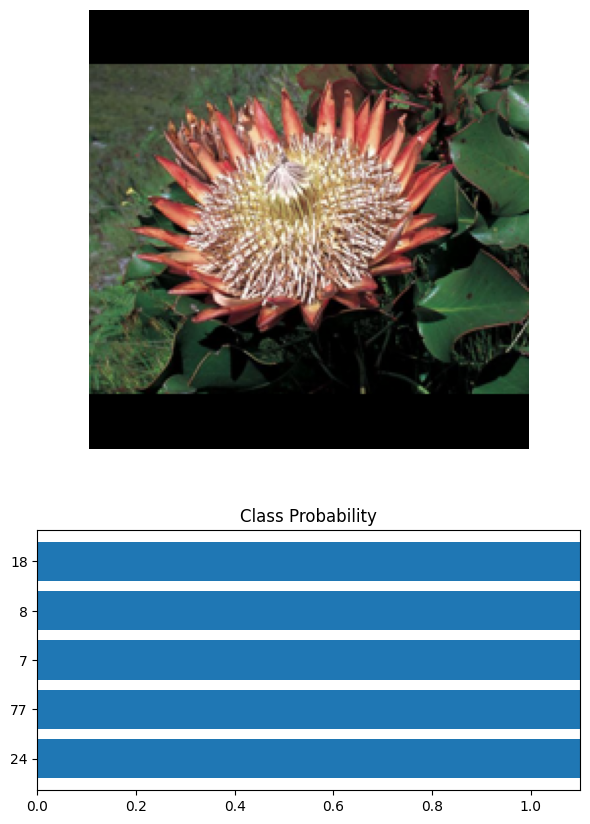

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import json

def plot_solution(image, probs, classes, class_names, topk=5):
    """Display an image along with the top K class probabilities."""

    # Create subplots with two rows: one for the image and one for the bar graph
    fig, (ax1, ax2) = plt.subplots(figsize=(6, 9), nrows=2)

    # Transpose the dimensions to (height, width, channels)
    image = image.transpose((1, 2, 0))

    # Undo preprocessing
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    # Display the image
    ax1.imshow(image)
    ax1.axis('off')

    # Convert class indices to class names
    class_names = [class_names[class_idx] for class_idx in classes]

    # Create a bar graph for the top K class probabilities
    ax2.barh(np.arange(topk), probs)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(topk))
    ax2.set_yticklabels(class_names)
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

# Define class_to_name mapping (starting from 1)
class_to_name = {
    'class1': 1,
    'class2': 2,
    'class3': 3,
    'class4': 4,
    'class5': 5,
    'class6': 6,
    'class7': 7,
    'class8': 8,
    'class9': 9,
    'class10': 10,
    'class11': 11,
    'class12': 12,
    'class13': 13,
    'class14': 14,
    'class15': 15,
    'class16': 16,
    'class17': 17,
    'class18': 18,
    'class19': 19,
    'class20': 20,
    'class21': 21,
    'class22': 22,
    'class23': 23,
    'class24': 24,
    'class25': 25,
    'class26': 26,
    'class27': 27,
    'class28': 28,
    'class29': 29,
    'class30': 30,
    'class31': 31,
    'class32': 32,
    'class33': 33,
    'class34': 34,
    'class35': 35,
    'class36': 36,
    'class37': 37,
    'class38': 38,
    'class39': 39,
    'class40': 40,
    'class41': 41,
    'class42': 42,
    'class43': 43,
    'class44': 44,
    'class45': 45,
    'class46': 46,
    'class47': 47,
    'class48': 48,
    'class49': 49,
    'class50': 50,
    'class51': 51,
    'class52': 52,
    'class53': 53,
    'class54': 54,
    'class55': 55,
    'class56': 56,
    'class57': 57,
    'class58': 58,
    'class59': 59,
    'class60': 60,
    'class61': 61,
    'class62': 62,
    'class63': 63,
    'class64': 64,
    'class65': 65,
    'class66': 66,
    'class67': 67,
    'class68': 68,
    'class69': 69,
    'class70': 70,
    'class71': 71,
    'class72': 72,
    'class73': 73,
    'class74': 74,
    'class75': 75,
    'class76': 76,
    'class77': 77,
    'class78': 78,
    'class79': 79,
    'class80': 80,
    'class81': 81,
    'class82': 82,
    'class83': 83,
    'class84': 84,
    'class85': 85,
    'class86': 86,
    'class87': 87,
    'class88': 88,
    'class89': 89,
    'class90': 90,
    'class91': 91,
    'class92': 92,
    'class93': 93,
    'class94': 94,
    'class95': 95,
    'class96': 96,
    'class97': 97,
    'class98': 98,
    'class99': 99,
    'class100': 100,
    'class101': 101,
    'class102': 102,  # If your model has 102 classes
}

# Example usage:
# Assuming you have the following variables:
# - processed_image: The processed image as a NumPy array
# - top_p: Top K probabilities as a list
# - top_class: Top K class indices as a list
# - topk: Number of top classes to display (default is 5)

# Plot the image and probabilities
plot_solution(processed_image, top_p, top_class, class_to_name, topk=5)
plt.show()

## Reminder for Workspace users
If your network becomes very large when saved as a checkpoint, there might be issues with saving backups in your workspace. You should reduce the size of your hidden layers and train again.
    
We strongly encourage you to delete these large interim files and directories before navigating to another page or closing the browser tab.

In [59]:
import os
import shutil

# Define the source directory containing .pth files
source_directory = './'

# Define the destination directory (temporary directory)
destination_directory = '/root/opt'  # Use an absolute path

# List all files in the source directory
files = os.listdir(source_directory)

# Ensure the destination directory exists; create it if necessary
os.makedirs(destination_directory, exist_ok=True)

# Iterate through the files and move them to the destination directory
for file in files:
    if file.endswith('.pth'):
        source_file = os.path.join(source_directory, file)
        destination_file = os.path.join(destination_directory, file)
        shutil.move(source_file, destination_file)

print("Files moved successfully.")

Files moved successfully.
